### Catalog Data Parsing

Based on the provided catalog format, each entry is 32 bytes long and contains the following fields:

*   `Real*4 XNO`: Catalog number of star (float, 4 bytes)
*   `Real*8 SRA0`: B1950 Right Ascension in radians (double, 8 bytes)
*   `Real*8 SDEC0`: B1950 Declination in radians (double, 8 bytes)
*   `Character*2 IS`: Spectral type (2-byte string)
*   `Integer*2 MAG`: V Magnitude * 100 (short integer, 2 bytes)
*   `Real*4 XRPM`: R.A. proper motion in radians per year (float, 4 bytes)
*   `Real*4 XDPM`: Dec. proper motion in radians per year (float, 4 bytes)

We will use the `struct` module to unpack this binary data.

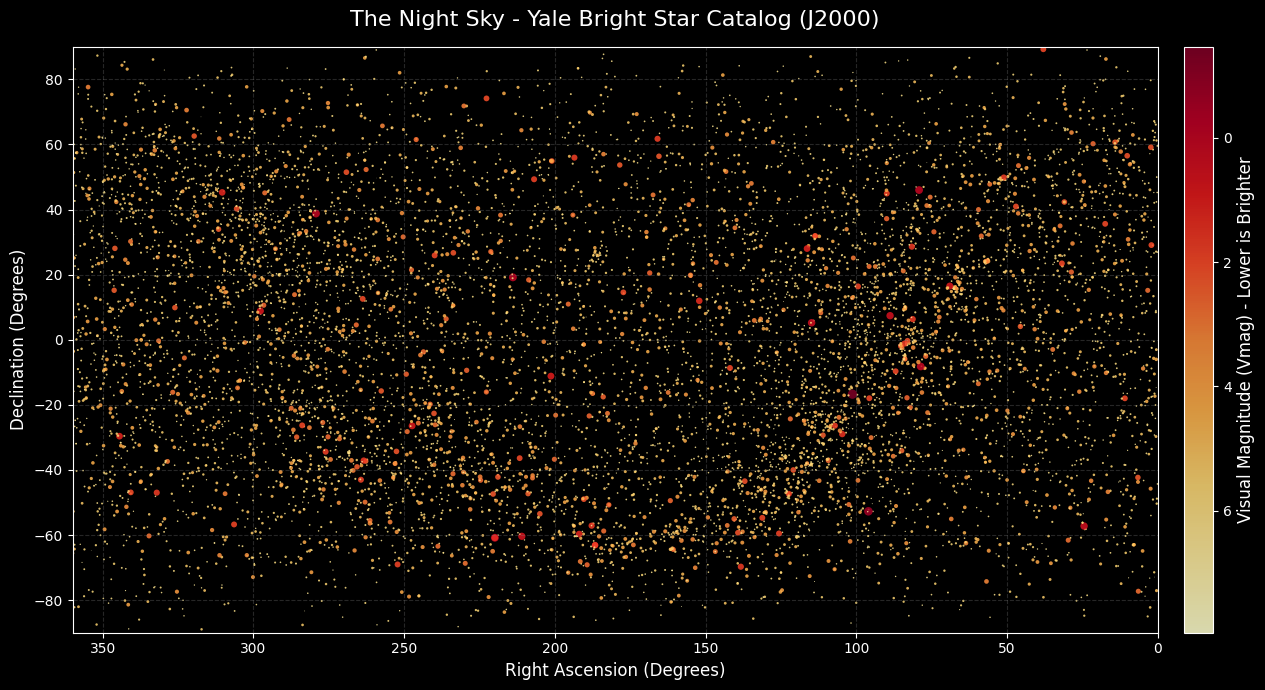

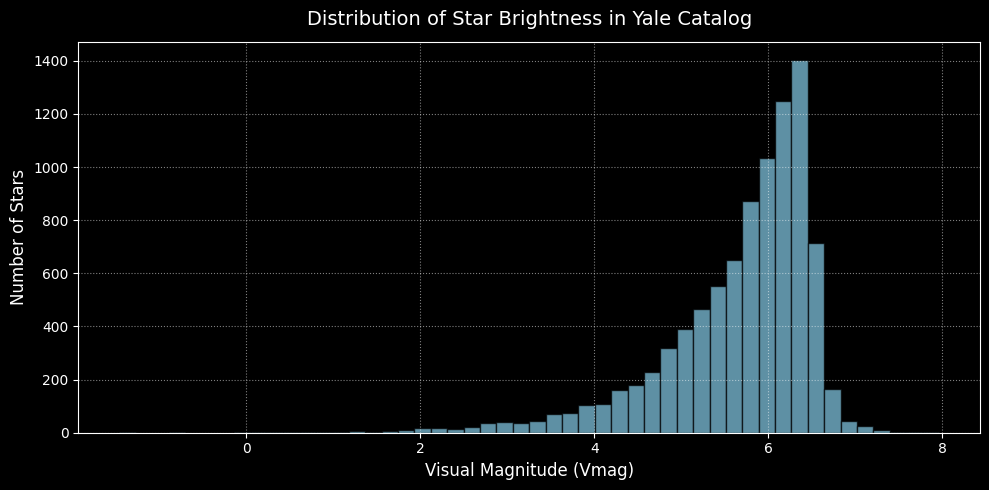

(=`ω´=) Both image files saved successfully!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Parse the fixed-width file accurately as strings
column_specs = [
    (0, 4),      # HR Number
    (75, 83),    # J2000 RA string
    (83, 90),    # J2000 DEC string
    (102, 107)   # Visual Magnitude string
]
column_names = ['HR', 'RA_str', 'DEC_str', 'Vmag_str']

df = pd.read_fwf('catalog.bin', colspecs=column_specs, names=column_names, header=None, dtype=str)

# 2. Conversion helper functions to change strings into float degrees
def parse_ra(val):
    if pd.isna(val): return np.nan
    val = str(val).strip()
    if len(val) < 6: return np.nan
    try:
        h = float(val[0:2])
        m = float(val[2:4])
        s = float(val[4:])
        return (h + m/60.0 + s/3600.0) * 15.0  # 15 degrees per hour
    except:
        return np.nan

def parse_dec(val):
    if pd.isna(val): return np.nan
    val = str(val).strip()
    if len(val) < 6: return np.nan
    try:
        sign = -1.0 if val[0] == '-' else 1.0
        if val[0] in ['+', '-']:
            d = float(val[1:3])
            m = float(val[3:5])
            s = float(val[5:])
        else:
            d = float(val[0:2])
            m = float(val[2:4])
            s = float(val[4:])
            sign = 1.0
        return sign * (d + m/60.0 + s/3600.0)
    except:
        return np.nan

# Apply cleaning and parsing
df['RA_deg'] = df['RA_str'].apply(parse_ra)
df['DEC_deg'] = df['DEC_str'].apply(parse_dec)
df['Vmag'] = pd.to_numeric(df['Vmag_str'], errors='coerce')

# Drop any rows with broken/missing coordinates
df_clean = df.dropna(subset=['RA_deg', 'DEC_deg', 'Vmag']).copy()

# Calculate exponential sizing so brighter stars stand out visually
df_clean['marker_size'] = (8.0 - df_clean['Vmag']) ** 2.0 * 0.5

# 3. Plotting the Celestial Sphere Chart
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 7))

sc = ax.scatter(
    df_clean['RA_deg'],
    df_clean['DEC_deg'],
    s=df_clean['marker_size'],
    c=df_clean['Vmag'],
    cmap='YlOrRd_r',  # White/yellow for bright stars, fading to deep orange/red
    alpha=0.85,
    edgecolors='none'
)

ax.set_title("The Night Sky - Yale Bright Star Catalog (J2000)", fontsize=16, pad=15)
ax.set_xlabel("Right Ascension (Degrees)", fontsize=12)
ax.set_ylabel("Declination (Degrees)", fontsize=12)
ax.set_xlim(360, 0)  # Invert RA to match real-world astronomy observation grids
ax.set_ylim(-90, 90)
ax.grid(True, color='gray', linestyle='--', alpha=0.3)

# Add colorbar for star temperatures/magnitudes
cbar = fig.colorbar(sc, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label('Visual Magnitude (Vmag) - Lower is Brighter', fontsize=12)
cbar.ax.invert_yaxis()  # Invert so brighter negative numbers are near the top

plt.tight_layout()
plt.savefig('star_map.png', dpi=300)
plt.show()

# 4. Plotting the Magnitude Distribution Histogram
fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.hist(df_clean['Vmag'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax2.set_title("Distribution of Star Brightness in Yale Catalog", fontsize=14, pad=12)
ax2.set_xlabel("Visual Magnitude (Vmag)", fontsize=12)
ax2.set_ylabel("Number of Stars", fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('magnitude_distribution.png', dpi=300)
plt.show()

print("(=`ω´=) Both image files saved successfully!")

<>:91: SyntaxWarning: invalid escape sequence '\l'
<>:91: SyntaxWarning: invalid escape sequence '\l'
C:\Users\PC\AppData\Local\Temp\ipykernel_27452\940164465.py:91: SyntaxWarning: invalid escape sequence '\l'
  mag_title = 'All Stars' if mag_cutoff is None else f'Vmag $\leq$ {mag_cutoff}'


New Random Central Point: RA = 248.89 deg, DEC = 8.23 deg


C:\Users\PC\AppData\Local\Temp\ipykernel_27452\940164465.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.05, 0.03, 0.9, 0.95]) # Adjust rect to make space for suptitle and global colorbar


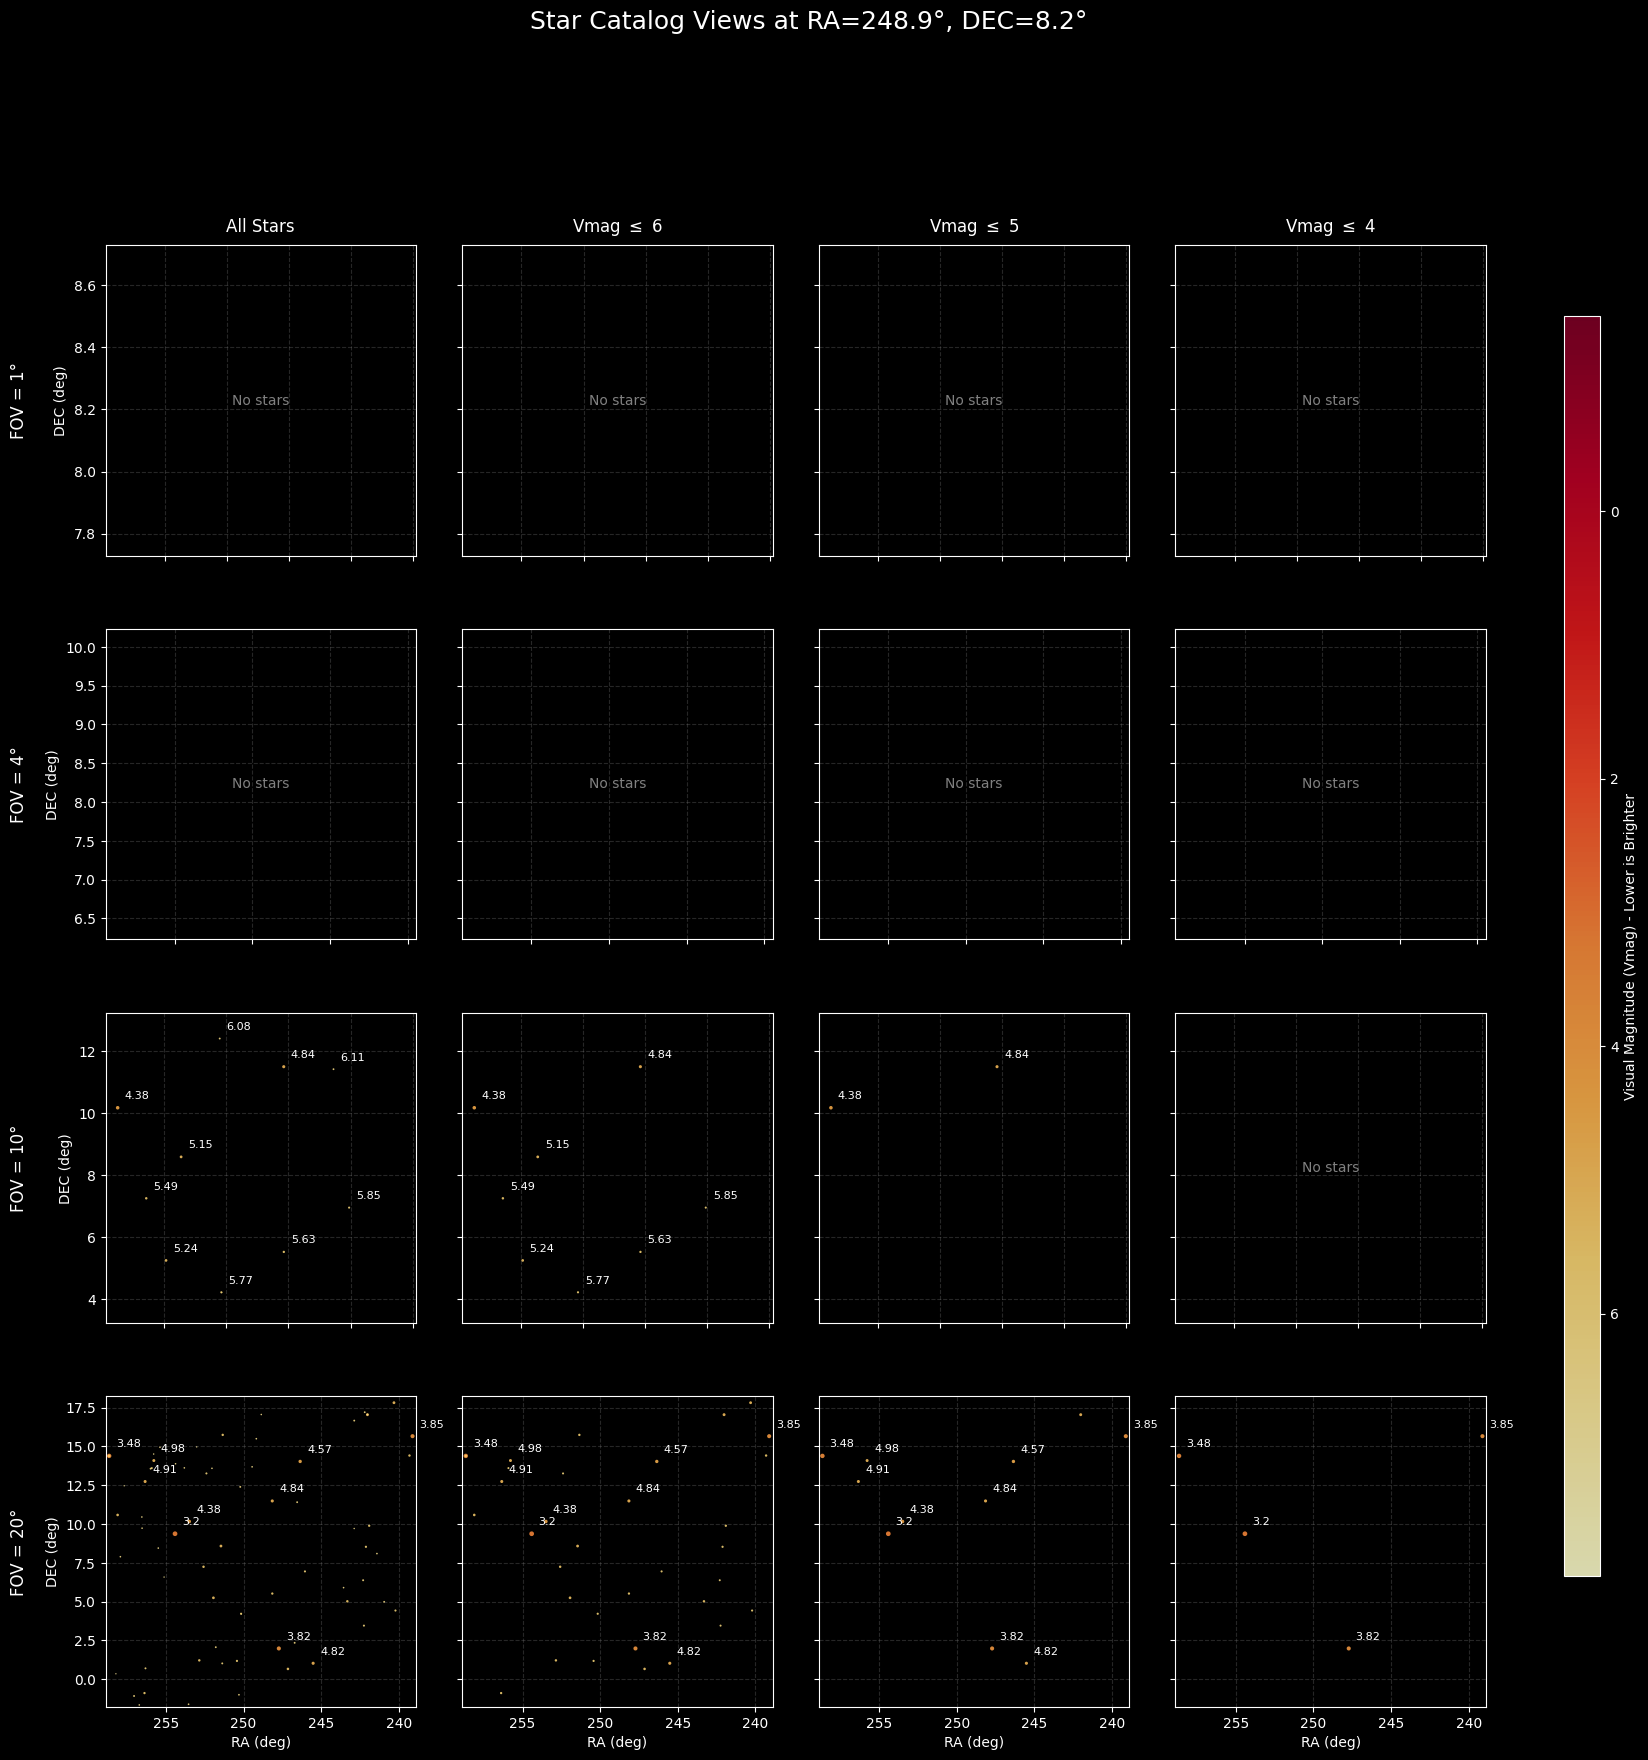

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Reuse the filter_stars_by_fov function from the previous cell
# Helper function to filter stars within a given FOV
def filter_stars_by_fov(df, center_ra, center_dec, fov):
    # Calculate RA limits, handling wrap-around at 0/360 degrees
    ra_min = center_ra - fov / 2.0
    ra_max = center_ra + fov / 2.0

    # Handle RA wrap-around
    if ra_min < 0:
        ra_condition = (df['RA_deg'] >= ra_min + 360) | (df['RA_deg'] <= ra_max)
    elif ra_max >= 360:
        ra_condition = (df['RA_deg'] >= ra_min) | (df['RA_deg'] <= ra_max - 360)
    else:
        ra_condition = (df['RA_deg'] >= ra_min) & (df['RA_deg'] <= ra_max)

    # Calculate DEC limits, clamping to -90/90 degrees
    dec_min = max(-90, center_dec - fov / 2.0)
    dec_max = min(90, center_dec + fov / 2.0)
    dec_condition = (df['DEC_deg'] >= dec_min) & (df['DEC_deg'] <= dec_max)

    return df[ra_condition & dec_condition].copy()


# 1. Select a new random central RA and DEC for this comparison
random_central_ra = np.random.uniform(0, 360)
random_central_dec = np.random.uniform(-90, 90)

print(f"New Random Central Point: RA = {random_central_ra:.2f} deg, DEC = {random_central_dec:.2f} deg")

# Define the FOV values (rows)
fov_degrees = [1, 4, 10, 20]
# Define magnitude cutoffs (columns): None for all, then Vmag <= cutoff
magnitude_cutoffs = [None, 6, 5, 4]

plt.style.use('dark_background')
fig, axes = plt.subplots(len(fov_degrees), len(magnitude_cutoffs), figsize=(4.5 * len(magnitude_cutoffs), 4.5 * len(fov_degrees)), squeeze=False)
fig.suptitle(f"Star Catalog Views at RA={random_central_ra:.1f}°, DEC={random_central_dec:.1f}°", fontsize=18, y=1.02)

for r_idx, fov in enumerate(fov_degrees):
    # Calculate plot limits for this FOV once, for consistent scaling in the row
    ra_plot_min = random_central_ra - fov / 2.0
    ra_plot_max = random_central_ra + fov / 2.0
    dec_plot_min = max(-90, random_central_dec - fov / 2.0)
    dec_plot_max = min(90, random_central_dec + fov / 2.0)

    # First, filter by FOV to avoid re-calculating for each magnitude cutoff
    stars_in_fov = filter_stars_by_fov(df_clean, random_central_ra, random_central_dec, fov)

    for c_idx, mag_cutoff in enumerate(magnitude_cutoffs):
        ax = axes[r_idx, c_idx]

        current_stars_to_plot = stars_in_fov.copy()
        if mag_cutoff is not None:
            current_stars_to_plot = current_stars_to_plot[current_stars_to_plot['Vmag'] <= mag_cutoff]

        if not current_stars_to_plot.empty:
            sc = ax.scatter(
                current_stars_to_plot['RA_deg'],
                current_stars_to_plot['DEC_deg'],
                s=current_stars_to_plot['marker_size'],
                c=current_stars_to_plot['Vmag'],
                cmap='YlOrRd_r', # White/yellow for bright stars, fading to deep orange/red
                alpha=0.85,
                edgecolors='none',
                vmin=df_clean['Vmag'].min(), # Set global vmin/vmax for consistent color mapping
                vmax=df_clean['Vmag'].max()
            )

            # Label the top 10 brightest stars
            # Sort by Vmag (lower is brighter) and take the top 10
            top_10_stars = current_stars_to_plot.sort_values(by='Vmag').head(10)

            for _, star in top_10_stars.iterrows():
                ax.annotate(
                    str(star['Vmag']), # Label with HR number
                    (star['RA_deg'], star['DEC_deg']),
                    xytext=(5, 5), # Offset text slightly from the point
                    textcoords='offset points',
                    ha='left',
                    va='bottom',
                    fontsize=8,
                    color='white' # White text for dark background
                )
        else:
            ax.text(0.5, 0.5, 'No stars', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, color='gray', fontsize=10)

        # Set titles for columns (magnitude cutoffs)
        mag_title = 'All Stars' if mag_cutoff is None else f'Vmag $\leq$ {mag_cutoff}'
        if r_idx == 0: # Only put column titles on the top row
            ax.set_title(mag_title, fontsize=12, pad=10)

        # Set titles for rows (FOV)
        if c_idx == 0: # Only put row titles on the left-most column
            ax.text(-0.25, 0.5, f'FOV = {fov}°', transform=ax.transAxes, rotation=90, va='center', ha='right', fontsize=12)

        # Set consistent limits for each plot in the row (based on FOV)
        ax.set_xlim(ra_plot_max, ra_plot_min) # Invert RA to match astronomical convention
        ax.set_ylim(dec_plot_min, dec_plot_max)

        ax.grid(True, color='gray', linestyle='--', alpha=0.3)
        ax.set_aspect('equal', adjustable='box') # Maintain aspect ratio

        # Hide tick labels for inner plots, keep for outer edges
        if r_idx < len(fov_degrees) - 1: # Hide x-ticks for all but the bottom row
            ax.set_xticklabels([])
        else: # Add x-label to the bottom row
            ax.set_xlabel('RA (deg)', fontsize=10)

        if c_idx > 0: # Hide y-ticks for all but the left-most column
            ax.set_yticklabels([])
        else: # Add y-label to the left-most column
            ax.set_ylabel('DEC (deg)', fontsize=10)

# Add a single colorbar for the entire figure
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) # [left, bottom, width, height]
fig.colorbar(sc, cax=cbar_ax, orientation='vertical', label='Visual Magnitude (Vmag) - Lower is Brighter')
cbar_ax.invert_yaxis() # Invert so brighter negative numbers are near the top

plt.tight_layout(rect=[0.05, 0.03, 0.9, 0.95]) # Adjust rect to make space for suptitle and global colorbar
plt.show()

In [3]:
import numpy as np
import pandas as pd
import itertools
import time

FOV_DEGREES     = 8.0
MAGNITUDE_LIMIT = 6.5
FOV_RAD         = np.radians(FOV_DEGREES)
MAX_TETRAS_PER_ANCHOR = 20
LOG_INTERVAL = 15

def mec_radius_batch(a_idx, b_idx, c_idx, d_indices, xs, ys):
    xa, ya = xs[a_idx], ys[a_idx]
    xb, yb = xs[b_idx], ys[b_idx]
    xc, yc = xs[c_idx], ys[c_idx]
    xd, yd = xs[d_indices], ys[d_indices]
    n_d    = len(d_indices)

    pts_x = np.stack([np.full(n_d,xa), np.full(n_d,xb), np.full(n_d,xc), xd], axis=1)
    pts_y = np.stack([np.full(n_d,ya), np.full(n_d,yb), np.full(n_d,yc), yd], axis=1)
    best  = np.full(n_d, np.inf)

    for i, j in itertools.combinations(range(4), 2):
        cx = (pts_x[:,i] + pts_x[:,j]) / 2
        cy = (pts_y[:,i] + pts_y[:,j]) / 2
        r  = np.hypot(pts_x[:,i]-cx, pts_y[:,i]-cy)
        ok = np.ones(n_d, dtype=bool)
        for k in range(4):
            ok &= np.hypot(pts_x[:,k]-cx, pts_y[:,k]-cy) <= r + 1e-10
        best = np.where(ok, np.minimum(best, r), best)

    for i, j, k in itertools.combinations(range(4), 3):
        ax=pts_x[:,i]; ay=pts_y[:,i]
        bx=pts_x[:,j]; by=pts_y[:,j]
        cx=pts_x[:,k]; cy=pts_y[:,k]
        D  = 2*(ax*(by-cy) + bx*(cy-ay) + cx*(ay-by))
        vD = np.abs(D) > 1e-12
        ux = np.where(vD, ((ax*ax+ay*ay)*(by-cy)+(bx*bx+by*by)*(cy-ay)+(cx*cx+cy*cy)*(ay-by))/np.where(vD,D,1), np.inf)
        uy = np.where(vD, ((ax*ax+ay*ay)*(cx-bx)+(bx*bx+by*by)*(ax-cx)+(cx*cx+cy*cy)*(bx-ax))/np.where(vD,D,1), np.inf)
        r  = np.hypot(ax-ux, ay-uy)
        ok = vD.copy()
        for m in range(4):
            ok &= np.hypot(pts_x[:,m]-ux, pts_y[:,m]-uy) <= r + 1e-10
        best = np.where(ok, np.minimum(best, r), best)

    return best

def angular_dist(ra1, dec1, ra2, dec2):
    """Great-circle distance in radians between two points."""
    dlon = ra2 - ra1
    dlat = dec2 - dec1
    a = np.sin(dlat/2)**2 + np.cos(dec1)*np.cos(dec2)*np.sin(dlon/2)**2
    return 2*np.arcsin(np.sqrt(np.clip(a, 0, 1)))

def get_feature_angular(ra_rad_4, dec_rad_4):
    """5-dim feature from 4 star positions using true angular separations.
    ra_rad_4, dec_rad_4: arrays of length 4, in radians.
    Returns float32 array (5,), or None if degenerate.
    """
    idx = [(0,1),(0,2),(1,2),(0,3),(1,3),(2,3)]   # AB AC BC AD BD CD
    edges = np.array([
        angular_dist(ra_rad_4[i], dec_rad_4[i], ra_rad_4[j], dec_rad_4[j])
        for i, j in idx
    ])
    edges.sort()
    if edges[-1] == 0:
        return None
    return (edges[:5] / edges[-1]).astype(np.float32)

# ── DB build: replace the xs/ys projection block with angular distances ────
# In get_feature_batch, replace the np.hypot calls with angular_dist:

def get_feature_batch_angular(a_idx, b_idx, c_idx, d_indices, ra_rad, dec_rad):
    n_d = len(d_indices)
    pairs = [(a_idx,b_idx),(a_idx,c_idx),(b_idx,c_idx)]  # fixed edges
    fixed = [angular_dist(ra_rad[i], dec_rad[i], ra_rad[j], dec_rad[j])
             for i, j in pairs]

    edges = np.zeros((n_d, 6), dtype=np.float64)
    edges[:, 0] = fixed[0]   # AB
    edges[:, 1] = fixed[1]   # AC
    edges[:, 2] = fixed[2]   # BC
    edges[:, 3] = angular_dist(ra_rad[a_idx], dec_rad[a_idx],
                               ra_rad[d_indices], dec_rad[d_indices])  # AD
    edges[:, 4] = angular_dist(ra_rad[b_idx], dec_rad[b_idx],
                               ra_rad[d_indices], dec_rad[d_indices])  # BD
    edges[:, 5] = angular_dist(ra_rad[c_idx], dec_rad[c_idx],
                               ra_rad[d_indices], dec_rad[d_indices])  # CD
    edges.sort(axis=1)
    max_e = edges[:, -1:]
    valid = max_e[:, 0] > 0
    feats = np.where(valid[:,None], edges[:,:5] / np.where(max_e>0, max_e, 1), 0)
    return feats.astype(np.float32), valid

# NOTE: angular_dist supports broadcasting — pass d_indices as array for rows 3-5.
# The MEC check (mec_radius_batch) also uses xs/ys; replace with angular version too
# — or keep the local projection there since MEC is just a filter, not stored.

# --- Prepare ---
df_clean['HR_clean'] = pd.to_numeric(df_clean['HR'], errors='coerce').fillna(-1).astype(int)
df_filtered = (df_clean[df_clean['Vmag'] <= MAGNITUDE_LIMIT]
               .copy().sort_values('Vmag').reset_index(drop=True))

ra_arr   = df_filtered['RA_deg'].values.astype(np.float64)
dec_arr  = df_filtered['DEC_deg'].values.astype(np.float64)
hr_arr   = df_filtered['HR_clean'].values
N        = len(df_filtered)
print(f"Stars: {N}  (Vmag ≤ {MAGNITUDE_LIMIT})")

# --- Neighbor lists ---
print("Precomputing neighbors...", end=' ', flush=True)
t0      = time.time()
ra_rad  = np.radians(ra_arr)
dec_rad = np.radians(dec_arr)
CHUNK   = 500
neighbors = [None]*N
nb_sets   = [None]*N

for start in range(0, N, CHUNK):
    end   = min(start+CHUNK, N)
    dlon  = ra_rad[None,:]  - ra_rad[start:end, None]
    dlat  = dec_rad[None,:] - dec_rad[start:end, None]
    a     = np.sin(dlat/2)**2 + np.cos(dec_rad[start:end,None])*np.cos(dec_rad[None,:])*np.sin(dlon/2)**2
    dist  = 2*np.arcsin(np.sqrt(np.clip(a,0,1)))
    for li, gi in enumerate(range(start, end)):
        mask = (dist[li] <= FOV_RAD) & (np.arange(N) > gi)
        idx  = np.where(mask)[0]
        neighbors[gi] = idx
        nb_sets[gi]   = set(idx.tolist())

print(f"done in {time.time()-t0:.1f}s")
print(f"Avg dimmer neighbors within FOV: {np.mean([len(x) for x in neighbors]):.1f}")

# --- Tangent plane projection (global, accurate enough for FOV≤12°) ---
ra_c  = ra_rad.mean()
dec_c = dec_rad.mean()
xs    = (ra_rad - ra_c) * np.cos(dec_c)
ys    =  dec_rad - dec_c

# --- Generation ---
print(f"Generating (FOV={FOV_DEGREES}°, cap={MAX_TETRAS_PER_ANCHOR}/anchor)...")
tetra_dict = {}
start_t    = time.time()
last_log   = start_t

for a_idx in range(N):
    now = time.time()
    if now - last_log >= LOG_INTERVAL:
        pct = a_idx/N*100
        el  = now - start_t
        eta = (N-a_idx)/(a_idx/el) if a_idx > 0 else 0
        print(f"  {pct:5.1f}% | {a_idx:5d}/{N} | tetras: {len(tetra_dict):,} | {el:.0f}s | ETA {eta:.0f}s")
        last_log = now

    nb_a = neighbors[a_idx]
    if len(nb_a) < 3:
        continue

    nb_a_set = nb_sets[a_idx]
    added    = 0

    for b_idx in nb_a:
        if added >= MAX_TETRAS_PER_ANCHOR:
            break
        ab_cands = neighbors[b_idx]
        ab_cands = ab_cands[np.isin(ab_cands, list(nb_a_set))]
        if len(ab_cands) < 2:
            continue
        ab_set = set(ab_cands.tolist())

        for c_idx in ab_cands:
            if added >= MAX_TETRAS_PER_ANCHOR:
                break
            abc_cands = neighbors[c_idx]
            abc_cands = abc_cands[np.isin(abc_cands, list(ab_set))]
            if len(abc_cands) == 0:
                continue

            # MEC filter — still uses xs/ys projection (fine, result not stored)
            mec_r   = mec_radius_batch(a_idx, b_idx, c_idx, abc_cands, xs, ys)
            valid_d = abc_cands[mec_r <= FOV_RAD/2]
            if len(valid_d) == 0:
                continue

            # ← FIX: use angular feature function, pass ra_rad/dec_rad not xs/ys
            feats, fvalid = get_feature_batch_angular(
                a_idx, b_idx, c_idx, valid_d, ra_rad, dec_rad)

            for k, d_idx in enumerate(valid_d):
                if added >= MAX_TETRAS_PER_ANCHOR:
                    break
                if not fvalid[k]:
                    continue
                # ← FIX: store as 4 separate ints, not a tuple key
                hr_a = int(hr_arr[a_idx]); hr_b = int(hr_arr[b_idx])
                hr_c = int(hr_arr[c_idx]); hr_d = int(hr_arr[d_idx])
                key  = (hr_a, hr_b, hr_c, hr_d)
                if key in tetra_dict:
                    continue
                tetra_dict[key] = {
                    'hr_a': hr_a, 'hr_b': hr_b,
                    'hr_c': hr_c, 'hr_d': hr_d,
                    'f1': feats[k,0], 'f2': feats[k,1],
                    'f3': feats[k,2], 'f4': feats[k,3],
                    'f5': feats[k,4],
                }
                added += 1

elapsed = time.time() - start_t
# ← Build DataFrame from values only (key was just for dedup)
df_tetra_db = pd.DataFrame(tetra_dict.values())
est_mb = len(df_tetra_db) * 100 / 1024**2
print(f"Unique tetras: {len(df_tetra_db):,}  |  {elapsed:.1f}s  |  ~{est_mb:.2f} MB")
df_tetra_db.to_csv('tetra_database_v9.csv', index=False)
try:
    from google.colab import files
    files.download('tetra_database_v9.csv')
except ImportError:
    pass

Stars: 8404  (Vmag ≤ 6.5)
Precomputing neighbors... done in 6.8s
Avg dimmer neighbors within FOV: 23.2
Generating (FOV=8.0°, cap=20/anchor)...
    8.7% |   730/8404 | tetras: 14,331 | 15s | ETA 160s
   17.9% |  1504/8404 | tetras: 29,504 | 30s | ETA 139s
   24.6% |  2067/8404 | tetras: 40,326 | 45s | ETA 139s
   32.8% |  2753/8404 | tetras: 53,358 | 60s | ETA 124s
   40.2% |  3378/8404 | tetras: 64,955 | 75s | ETA 112s
   48.9% |  4106/8404 | tetras: 78,345 | 90s | ETA 94s
   58.8% |  4940/8404 | tetras: 92,810 | 105s | ETA 74s
   65.1% |  5475/8404 | tetras: 101,228 | 120s | ETA 64s
   73.0% |  6135/8404 | tetras: 110,300 | 135s | ETA 50s
   85.1% |  7148/8404 | tetras: 119,370 | 150s | ETA 26s
Unique tetras: 121,579  |  155.1s  |  ~11.59 MB


In [4]:
db_features = df_tetra_db[['f1','f2','f3','f4','f5']].values.astype(np.float32)  # ← ADD THIS

In [5]:
# ── Load DB (run this if you're re-running identification without rebuilding) ──
import pandas as pd
import numpy as np

df_tetra_db = pd.read_csv('tetra_database_v9.csv')
db_features = df_tetra_db[['f1','f2','f3','f4','f5']].values.astype(np.float32)
print(f"Loaded {len(df_tetra_db):,} tetras. db_features shape: {db_features.shape}")

Loaded 121,579 tetras. db_features shape: (121579, 5)


In [6]:
def get_query_feature(stars_4):
    """No center_ra/dec needed — angular distances are absolute."""
    ra  = np.radians(stars_4['RA_deg'].values)
    dec = np.radians(stars_4['DEC_deg'].values)
    return get_feature_angular(ra, dec)   # same function as DB build

In [7]:
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
from collections import defaultdict

# ═══════════════════════════════════════════════════════════════════════════════
# CELL 1 — Shared helpers (run once)
# ═══════════════════════════════════════════════════════════════════════════════

print("Building HR → tetra index...", end=" ", flush=True)
hr_to_rows = defaultdict(set)
for row_i, row in df_tetra_db.iterrows():
    for col in ('hr_a', 'hr_b', 'hr_c', 'hr_d'):
        hr_to_rows[int(row[col])].add(row_i)
print(f"done. {len(hr_to_rows):,} unique HR IDs indexed.")

print("Building frozenset tetra set...", end=" ", flush=True)
db_tetra_sets = set(
    frozenset([int(r.hr_a), int(r.hr_b), int(r.hr_c), int(r.hr_d)])
    for _, r in df_tetra_db.iterrows()
)
print(f"done. {len(db_tetra_sets):,} unique tetras.")


def query_stars_for_fov(test_ra, test_dec, fov_deg, mag_limit=None):
    """
    Stars in FOV filtered to mag_limit (same stars as DB build).
    fov_deg is REQUIRED — always pass it explicitly so callers can't
    accidentally fall back to a global constant.
    """
    if mag_limit is None:
        mag_limit = MAGNITUDE_LIMIT
    stars = filter_stars_by_fov(df_clean, test_ra, test_dec, fov_deg)
    stars = stars[stars['Vmag'] <= mag_limit].copy()
    return stars.sort_values('Vmag').reset_index(drop=True)


def _is_identified(matched_ids, fov_hr_set):
    """
    FIX (Bug 2): identification succeeds when all 4 matched star IDs are
    visible in the FOV — regardless of which query combo triggered the match.
    """
    return all(hid in fov_hr_set for hid in matched_ids)


Building HR → tetra index... done. 8,338 unique HR IDs indexed.
Building frozenset tetra set... done. 121,579 unique tetras.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2 — Sky Coverage
# ═══════════════════════════════════════════════════════════════════════════════

def calculate_coverage_accuracy(n_samples=500, fov_deg=10.0, mag_limit=None):
    if mag_limit is None:
        mag_limit = MAGNITUDE_LIMIT
    print(f"Sky Coverage Test | {n_samples} samples | FOV={fov_deg}° | mag≤{mag_limit}")

    covered_count  = 0
    no_stars_count = 0

    for i in range(n_samples):
        test_ra  = np.random.uniform(0, 360)
        test_dec = np.random.uniform(-70, 70)

        stars      = query_stars_for_fov(test_ra, test_dec, fov_deg=fov_deg, mag_limit=mag_limit)
        hr_in_view = set(stars['HR_clean'].astype(int).values)

        if len(hr_in_view) < 4:
            no_stars_count += 1
            continue

        covered  = False
        hr_list  = list(hr_in_view)
        checked  = set()
        for hr in hr_list:
            for row_i in hr_to_rows.get(hr, set()):
                if row_i in checked:
                    continue
                checked.add(row_i)
                row   = df_tetra_db.iloc[row_i]
                tetra = {int(row.hr_a), int(row.hr_b), int(row.hr_c), int(row.hr_d)}
                if tetra.issubset(hr_in_view):
                    covered = True
                    break
            if covered:
                break

        if covered:
            covered_count += 1

        if (i + 1) % 100 == 0:
            valid_so_far = i + 1 - no_stars_count
            pct = covered_count / valid_so_far * 100 if valid_so_far > 0 else 0
            print(f"  {i+1}/{n_samples} | coverage so far: {pct:.1f}%")

    valid_samples = n_samples - no_stars_count
    accuracy      = covered_count / valid_samples * 100 if valid_samples > 0 else 0
    print(f"\n─── COVERAGE RESULTS ───────────────────────────────")
    print(f"  Total samples   : {n_samples}")
    print(f"  Sparse sky (<4) : {no_stars_count}")
    print(f"  Valid samples   : {valid_samples}")
    print(f"  Covered         : {covered_count}")
    print(f"  Sky Coverage    : {accuracy:.2f}%")
    print(f"  Blind Spot Rate : {100 - accuracy:.2f}%")
    return accuracy

coverage = calculate_coverage_accuracy(n_samples=500, fov_deg=10.0)


Sky Coverage Test | 500 samples | FOV=10.0° | mag≤6.5
  100/500 | coverage so far: 94.9%
  200/500 | coverage so far: 97.0%
  300/500 | coverage so far: 97.3%
  400/500 | coverage so far: 97.2%
  500/500 | coverage so far: 97.6%

─── COVERAGE RESULTS ───────────────────────────────
  Total samples   : 500
  Sparse sky (<4) : 3
  Valid samples   : 497
  Covered         : 485
  Sky Coverage    : 97.59%
  Blind Spot Rate : 2.41%


Boresight: RA 258.89°  Dec 17.70°  Roll 267.49°
Stars in FOV (mag≤6.5): 23
✅ combo 1  score=2.25e-04
   Matched IDs: [6337, 6355, 6407, 6452]
   All in FOV:  True


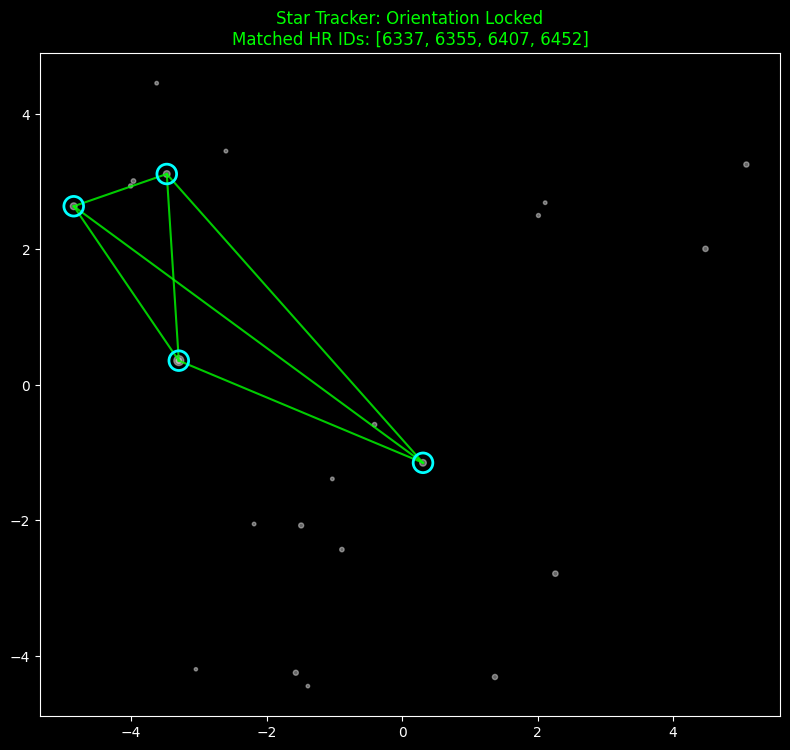

(True, [6337, 6355, 6407, 6452], 0.0002245511277578771)

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3 — Single Identification Test
# ═══════════════════════════════════════════════════════════════════════════════

def run_single_id_test(obs_ra=None, obs_dec=None, obs_roll=None,
                       fov_deg=10.0, match_threshold=0.003,
                       max_stars_query=10, verbose=True):
    if obs_ra   is None: obs_ra   = np.random.uniform(0, 360)
    if obs_dec  is None: obs_dec  = np.random.uniform(-70, 70)
    if obs_roll is None: obs_roll = np.random.uniform(0, 360)

    if verbose:
        print(f"Boresight: RA {obs_ra:.2f}°  Dec {obs_dec:.2f}°  Roll {obs_roll:.2f}°")

    visible_stars = query_stars_for_fov(obs_ra, obs_dec, fov_deg=fov_deg)
    fov_hr_set    = set(visible_stars['HR_clean'].astype(int).values)

    if verbose:
        print(f"Stars in FOV (mag≤{MAGNITUDE_LIMIT}): {len(visible_stars)}")

    if len(visible_stars) < 4:
        if verbose: print("❌ Not enough stars.")
        return False, None, None

    candidate_pool = visible_stars.head(max_stars_query)
    star_combos    = list(itertools.combinations(range(len(candidate_pool)), 4))

    for i, combo_indices in enumerate(star_combos):
        query_stars = candidate_pool.iloc[list(combo_indices)]
        query_vec   = get_query_feature(query_stars)
        if query_vec is None:
            continue

        distances = np.linalg.norm(db_features - query_vec, axis=1)
        best_idx  = int(np.argmin(distances))
        score     = float(distances[best_idx])

        if score < match_threshold:
            row         = df_tetra_db.iloc[best_idx]
            matched_ids = sorted([int(row['hr_a']), int(row['hr_b']),
                                   int(row['hr_c']), int(row['hr_d'])])
            # FIX Bug 2: correct = matched stars are ALL in the visible FOV
            correct = _is_identified(matched_ids, fov_hr_set)

            if verbose:
                print(f"{'✅' if correct else '⚠️ NOT IN FOV'} combo {i+1}  score={score:.2e}")
                print(f"   Matched IDs: {matched_ids}")
                print(f"   All in FOV:  {correct}")

            if correct:
                if verbose:
                    _plot_id_result(obs_ra, obs_dec, obs_roll, visible_stars, matched_ids)
                return True, matched_ids, score
            # FIX Bug 3: matched IDs not in FOV → keep searching (don't stop)

    if verbose:
        print("❌ FAILURE: No valid match found.")
    return False, None, None


def _plot_id_result(obs_ra, obs_dec, obs_roll, visible_stars, matched_ids):
    plt.style.use('dark_background')
    fig, ax = plt.subplots(figsize=(8, 8))
    vis_x  = (visible_stars['RA_deg'] - obs_ra) * np.cos(np.radians(obs_dec))
    vis_y  =  visible_stars['DEC_deg'] - obs_dec
    rot_x  = vis_x * np.cos(np.radians(obs_roll)) - vis_y * np.sin(np.radians(obs_roll))
    rot_y  = vis_x * np.sin(np.radians(obs_roll)) + vis_y * np.cos(np.radians(obs_roll))
    ax.scatter(rot_x, rot_y, s=visible_stars['marker_size']*5, color='white', alpha=0.4)
    match_stars = visible_stars[visible_stars['HR_clean'].astype(int).isin(matched_ids)]
    m_x  = (match_stars['RA_deg'] - obs_ra) * np.cos(np.radians(obs_dec))
    m_y  =  match_stars['DEC_deg'] - obs_dec
    mr_x = m_x * np.cos(np.radians(obs_roll)) - m_y * np.sin(np.radians(obs_roll))
    mr_y = m_x * np.sin(np.radians(obs_roll)) + m_y * np.cos(np.radians(obs_roll))
    ax.scatter(mr_x, mr_y, s=200, facecolors='none', edgecolors='cyan', linewidth=2, zorder=10)
    for p1, p2 in itertools.combinations(zip(mr_x.values, mr_y.values), 2):
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color='lime', alpha=0.8, lw=1.5)
    ax.set_title(f"Star Tracker: Orientation Locked\nMatched HR IDs: {matched_ids}",
                 color='lime', fontsize=12)
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()


run_single_id_test()



In [9]:

# ═══════════════════════════════════════════════════════════════════════════════
# CELL 4 — Batch Identification Accuracy
# ═══════════════════════════════════════════════════════════════════════════════

def run_batch_id_test(n_samples=500, fov_deg=10.0, match_threshold=0.003,
                      max_stars_query=10, seed=42, mag_limit=7.0):
    rng = np.random.default_rng(seed)
    print(f"Batch ID Test | {n_samples} samples | FOV={fov_deg}° | "
          f"thresh={match_threshold} | top-{max_stars_query} stars | mag_limit={mag_limit}")

    results = []
    for i in range(n_samples):
        obs_ra   = float(rng.uniform(0, 360))
        obs_dec  = float(rng.uniform(-70, 70))
        obs_roll = float(rng.uniform(0, 360))

        # Pass the mag_limit to query_stars_for_fov
        visible    = query_stars_for_fov(obs_ra, obs_dec, fov_deg=fov_deg, mag_limit=mag_limit)
        n_stars    = len(visible)
        fov_hr_set = set(visible['HR_clean'].astype(int).values)

        if n_stars < 4:
            results.append({
                'ra': obs_ra, 'dec': obs_dec, 'roll': obs_roll,
                'n_stars': n_stars, 'outcome': 'sparse',
                'score': np.nan, 'correct': False
            })
            continue

        candidate_pool = visible.head(max_stars_query)
        outcome        = 'failure'
        best_score     = np.nan

        for combo_indices in itertools.combinations(range(len(candidate_pool)), 4):
            query_stars = candidate_pool.iloc[list(combo_indices)]
            query_vec   = get_query_feature(query_stars)
            if query_vec is None:
                continue

            distances = np.linalg.norm(db_features - query_vec, axis=1)
            best_idx  = int(np.argmin(distances))
            score     = float(distances[best_idx])

            # Track best score seen (for analysis), regardless of threshold
            if np.isnan(best_score) or score < best_score:
                best_score = score

            if score < match_threshold:
                row         = df_tetra_db.iloc[best_idx]
                matched_ids = sorted([int(row['hr_a']), int(row['hr_b']),
                                       int(row['hr_c']), int(row['hr_d'])])
                # FIX Bug 2+3: check FOV membership, keep going if wrong
                if _is_identified(matched_ids, fov_hr_set):
                    outcome = 'correct'
                    break
                # else: valid NN score but matched stars not in FOV → false positive, continue

        results.append({
            'ra': obs_ra, 'dec': obs_dec, 'roll': obs_roll,
            'n_stars': n_stars, 'outcome': outcome,
            'score': best_score, 'correct': (outcome == 'correct'),
            'fov_deg': fov_deg
        })

        if (i + 1) % 100 == 0:
            sf      = pd.DataFrame(results)
            valid   = sf[sf['outcome'] != 'sparse']
            acc     = valid['correct'].mean() * 100 if len(valid) else 0
            fail_n  = (valid['outcome'] == 'failure').sum()
            print(f"  {i+1}/{n_samples} | acc={acc:.1f}% | failures={fail_n}")

    df_results = pd.DataFrame(results)
    _print_batch_summary(df_results)
    return df_results


def _print_batch_summary(df):
    total   = len(df)
    sparse  = (df['outcome'] == 'sparse').sum()
    valid   = df[df['outcome'] != 'sparse']
    correct = (valid['outcome'] == 'correct').sum()
    failure = (valid['outcome'] == 'failure').sum()
    acc     = correct / len(valid) * 100 if len(valid) else 0
    print(f"\n─── BATCH ID RESULTS ───────────────────────────────")
    print(f"  Total samples    : {total}")
    print(f"  Sparse (<4 stars): {sparse}")
    print(f"  Valid attempts   : {len(valid)}")
    print(f"  ✅ Correct        : {correct}  ({acc:.2f}%)")
    print(f"  ❌ Failures       : {failure}  ({failure/len(valid)*100:.2f}%")


df_results = run_batch_id_test(n_samples=500, fov_deg=10.0)


Batch ID Test | 500 samples | FOV=10.0° | thresh=0.003 | top-10 stars | mag_limit=7.0
  100/500 | acc=87.9% | failures=12
  200/500 | acc=91.0% | failures=18
  300/500 | acc=91.3% | failures=26
  400/500 | acc=91.7% | failures=33
  500/500 | acc=92.0% | failures=40

─── BATCH ID RESULTS ───────────────────────────────
  Total samples    : 500
  Sparse (<4 stars): 3
  Valid attempts   : 497
  ✅ Correct        : 457  (91.95%)
  ❌ Failures       : 40  (8.05%


Analyzing 40 failure cases...

─── FAILURE BREAKDOWN ──────────────────────────────
  Total failures             : 40
  DB has a tetra for view    : 18 (45.0%)
  ↳ Threshold too tight      : 3 — raise threshold
  ↳ Correct tetra not top NN : 15 — feature collision in DB
  No tetra in DB for view    : 22 — genuine coverage gap

  Threshold suggestion (to recover threshold-fixable failures):
    p95 of valid-match scores = 0.02294
    p99 of valid-match scores = 0.02341  ← recommended

  best_score_valid stats (failures where correct NN exists):
    median : 0.01771
    mean   : 0.01686
    max    : 0.02352


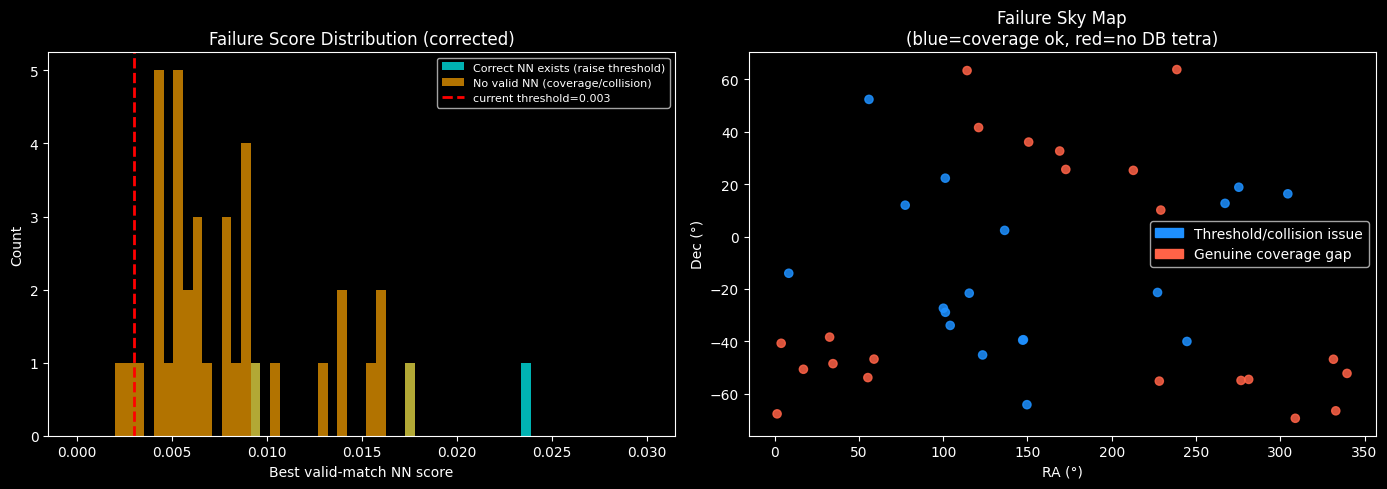


─── TOP 15 FAILURES BY SCORE ─────────────────────────
        ra        dec  n_stars  n_in_pool  db_covered  best_score_valid  best_score_any
275.399589  18.860565       26         10        True               inf        0.006519
101.298201 -28.896874       33         10        True               inf        0.005446
149.690665 -64.174016       20         10        True               inf        0.005086
101.244162  22.319169       18         10        True               inf        0.004436
276.713097 -54.916268        7          7       False               inf        0.004092
114.170001  63.405915        5          5       False               inf        0.013912
238.631117  63.787256        5          5       False               inf        0.015649
332.931035 -66.519671        4          4       False               inf        0.009002
228.231040 -55.174363        8          7       False               inf        0.007986
331.549370 -46.825559        6          5       False           

In [10]:

# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5 — Failure Analysis
# ═══════════════════════════════════════════════════════════════════════════════

def analyze_failures(df_results, match_threshold=0.003, max_stars_query=10, n_detail=15):
    """
    FIX Bug 1: fov_deg is read from df_results per-row (stored by run_batch_id_test),
    so every re-query uses the exact same FOV that was used during the batch run.
    """
    failures = df_results[df_results['outcome'] == 'failure'].copy()
    if len(failures) == 0:
        print("🎉 No failures!")
        return pd.DataFrame()

    print(f"Analyzing {len(failures)} failure cases...\n")
    diag_rows = []

    for _, row in failures.iterrows():
        fov_deg = float(row.get('fov_deg', FOV_DEGREES))   # FIX Bug 1
        stars   = query_stars_for_fov(row['ra'], row['dec'], fov_deg=fov_deg)
        hr_in_view = set(stars['HR_clean'].astype(int).values)

        # Is there a DB tetra fully in this view?
        covered  = False
        for hr in hr_in_view:
            for row_i in hr_to_rows.get(hr, set()):
                db_row = df_tetra_db.iloc[row_i]
                tetra  = {int(db_row.hr_a), int(db_row.hr_b),
                          int(db_row.hr_c), int(db_row.hr_d)}
                if tetra.issubset(hr_in_view):
                    covered = True
                    break
            if covered:
                break

        # Best NN score across all combos, with correct FOV membership check
        candidate_pool   = stars.head(max_stars_query)
        best_score_valid = np.inf   # best score where matched IDs ARE in FOV
        best_score_any   = np.inf   # best score regardless

        for combo_indices in itertools.combinations(range(len(candidate_pool)), 4):
            qs  = candidate_pool.iloc[list(combo_indices)]
            qv  = get_query_feature(qs)
            if qv is None:
                continue
            dists    = np.linalg.norm(db_features - qv, axis=1)
            best_idx = int(np.argmin(dists))
            s        = float(dists[best_idx])

            if s < best_score_any:
                best_score_any = s

            db_row      = df_tetra_db.iloc[best_idx]
            matched_ids = [int(db_row['hr_a']), int(db_row['hr_b']),
                           int(db_row['hr_c']), int(db_row['hr_d'])]
            if _is_identified(matched_ids, hr_in_view) and s < best_score_valid:
                best_score_valid = s

        diag_rows.append({
            'ra'              : row['ra'],
            'dec'             : row['dec'],
            'fov_deg'         : fov_deg,
            'n_stars'         : row['n_stars'],
            'n_in_pool'       : len(candidate_pool),
            'db_covered'      : covered,
            'best_score_any'  : best_score_any,
            'best_score_valid': best_score_valid,   # score of correct-FOV match
            'would_pass_at'   : best_score_valid,   # alias for clarity
        })

    df_diag = pd.DataFrame(diag_rows)

    # ── Classify ─────────────────────────────────────────────────────────────
    threshold_fixable = df_diag[
        df_diag['db_covered'] &
        (df_diag['best_score_valid'] < np.inf) &
        (df_diag['best_score_valid'] >= match_threshold)
    ]
    no_valid_nn    = df_diag[df_diag['db_covered'] & (df_diag['best_score_valid'] == np.inf)]
    coverage_gaps  = df_diag[~df_diag['db_covered']]

    print("─── FAILURE BREAKDOWN ──────────────────────────────")
    print(f"  Total failures             : {len(df_diag)}")
    print(f"  DB has a tetra for view    : {df_diag['db_covered'].sum()} "
          f"({df_diag['db_covered'].mean()*100:.1f}%)")
    print(f"  ↳ Threshold too tight      : {len(threshold_fixable)} — raise threshold")
    print(f"  ↳ Correct tetra not top NN : {len(no_valid_nn)} — feature collision in DB")
    print(f"  No tetra in DB for view    : {len(coverage_gaps)} — genuine coverage gap")

    # Suggest threshold
    valid_scores = df_diag.loc[
        df_diag['best_score_valid'] < np.inf, 'best_score_valid'
    ]
    if len(valid_scores):
        p95 = np.percentile(valid_scores, 95)
        p99 = np.percentile(valid_scores, 99)
        print(f"\n  Threshold suggestion (to recover threshold-fixable failures):")
        print(f"    p95 of valid-match scores = {p95:.5f}")
        print(f"    p99 of valid-match scores = {p99:.5f}  ← recommended")

    print(f"\n  best_score_valid stats (failures where correct NN exists):")
    if len(valid_scores):
        print(f"    median : {valid_scores.median():.5f}")
        print(f"    mean   : {valid_scores.mean():.5f}")
        print(f"    max    : {valid_scores.max():.5f}")

    # ── Plots ─────────────────────────────────────────────────────────────────
    plt.style.use('dark_background')
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    valid_s   = df_diag.loc[df_diag['best_score_valid'] < np.inf, 'best_score_valid']
    invalid_s = df_diag.loc[df_diag['best_score_valid'] == np.inf, 'best_score_any']
    invalid_s = invalid_s[invalid_s < np.inf]
    bins = np.linspace(0, max(
        valid_s.max() if len(valid_s) else 0.01,
        invalid_s.max() if len(invalid_s) else 0.01,
        match_threshold * 10
    ), 60)
    if len(valid_s):
        ax.hist(valid_s,   bins=bins, color='cyan',   alpha=0.7, label='Correct NN exists (raise threshold)')
    if len(invalid_s):
        ax.hist(invalid_s, bins=bins, color='orange', alpha=0.7, label='No valid NN (coverage/collision)')
    ax.axvline(match_threshold, color='red', lw=2, ls='--', label=f'current threshold={match_threshold}')
    ax.set_xlabel('Best valid-match NN score'); ax.set_ylabel('Count')
    ax.set_title('Failure Score Distribution (corrected)'); ax.legend(fontsize=8)

    ax2 = axes[1]
    colors = df_diag['db_covered'].map({True: 'dodgerblue', False: 'tomato'})
    ax2.scatter(df_diag['ra'], df_diag['dec'], c=colors, s=35, alpha=0.85)
    ax2.set_xlabel('RA (°)'); ax2.set_ylabel('Dec (°)')
    ax2.set_title('Failure Sky Map\n(blue=coverage ok, red=no DB tetra)')
    from matplotlib.patches import Patch
    ax2.legend(handles=[Patch(color='dodgerblue', label='Threshold/collision issue'),
                        Patch(color='tomato',     label='Genuine coverage gap')])
    plt.tight_layout()
    plt.show()

    print(f"\n─── TOP {n_detail} FAILURES BY SCORE ─────────────────────────")
    top = df_diag.nlargest(n_detail, 'best_score_valid')[
        ['ra','dec','n_stars','n_in_pool','db_covered','best_score_valid','best_score_any']
    ]
    print(top.to_string(index=False))

    return df_diag


df_diag = analyze_failures(df_results)


### Confusion Matrix Analysis

Let's evaluate the performance of the star identification system across various Field of View (FOV) and magnitude limit combinations to generate a confusion matrix.

In [ ]:
fov_values = [10.0, 12.0, 15.0, 18.0, 20.0]
mag_limits = [5.0, 5.5, 6.0, 6.5, None] # None represents 'ALL' stars (up to default MAGNITUDE_LIMIT)

results_matrix = []

print("Starting Confusion Matrix Analysis...")
print("This may take a while as it runs a batch test for each combination.")

for fov in fov_values:
    row_results = {'FOV': fov}
    for mag_limit in mag_limits:
        mag_label = f'< {mag_limit}' if mag_limit is not None else 'ALL'
        print(f"\nRunning batch test for FOV={fov}° and Mag Limit={mag_label}...")

        # Run the batch test with the current FOV and magnitude limit
        # Assuming `run_batch_id_test` uses `MAGNITUDE_LIMIT` if `mag_limit` is None
        # and `query_stars_for_fov` handles the mag_limit parameter correctly.
        batch_results_df = run_batch_id_test(
            n_samples=200, # Use a reasonable number of samples for each run
            fov_deg=fov,
            match_threshold=0.003, # Keep the default match threshold
            max_stars_query=15,
            seed=42, # Use a fixed seed for reproducibility across runs
            mag_limit=mag_limit # Pass the magnitude limit to the batch test
        )

        # Extract the overall accuracy
        valid_attempts = batch_results_df[batch_results_df['outcome'] != 'sparse']
        accuracy = valid_attempts['correct'].mean() * 100 if len(valid_attempts) > 0 else 0.0

        row_results[mag_label] = f"{accuracy:.2f}%"
    results_matrix.append(row_results)

confusion_df = pd.DataFrame(results_matrix)
display(confusion_df)
print("\nConfusion Matrix Analysis Complete.")


Starting Confusion Matrix Analysis...
This may take a while as it runs a batch test for each combination.

Running batch test for FOV=10.0° and Mag Limit=< 5.0...
Batch ID Test | 200 samples | FOV=10.0° | thresh=0.003 | top-15 stars | mag_limit=5.0
  100/200 | acc=64.7% | failures=12

─── BATCH ID RESULTS ───────────────────────────────
  Total samples    : 200
  Sparse (<4 stars): 133
  Valid attempts   : 67
  ✅ Correct        : 39  (58.21%) Jardian)
  ❌ Failures       : 28  (41.79%) Jardian)

Running batch test for FOV=10.0° and Mag Limit=< 5.5...
Batch ID Test | 200 samples | FOV=10.0° | thresh=0.003 | top-15 stars | mag_limit=5.5
  100/200 | acc=60.9% | failures=27
  200/200 | acc=64.5% | failures=49

─── BATCH ID RESULTS ───────────────────────────────
  Total samples    : 200
  Sparse (<4 stars): 62
  Valid attempts   : 138
  ✅ Correct        : 89  (64.49%) Jardian)
  ❌ Failures       : 49  (35.51%) Jardian)

Running batch test for FOV=10.0° and Mag Limit=< 6.0...
Batch ID Test |

,FOV,< 5.0,< 5.5,< 6.0,< 6.5,ALL
0,10.0,58.21%,64.49%,81.52%,93.97%,93.97%
1,12.0,54.46%,65.36%,89.95%,98.50%,98.50%
2,15.0,56.89%,80.81%,97.50%,99.50%,99.50%
3,18.0,65.97%,88.94%,100.00%,100.00%,100.00%
4,20.0,71.79%,90.50%,97.50%,97.50%,97.50%



Confusion Matrix Analysis Complete.


### Visualizing the Confusion Matrix

Let's visualize the generated accuracy confusion matrix as a heatmap to easily observe trends across different FOV and magnitude limits.

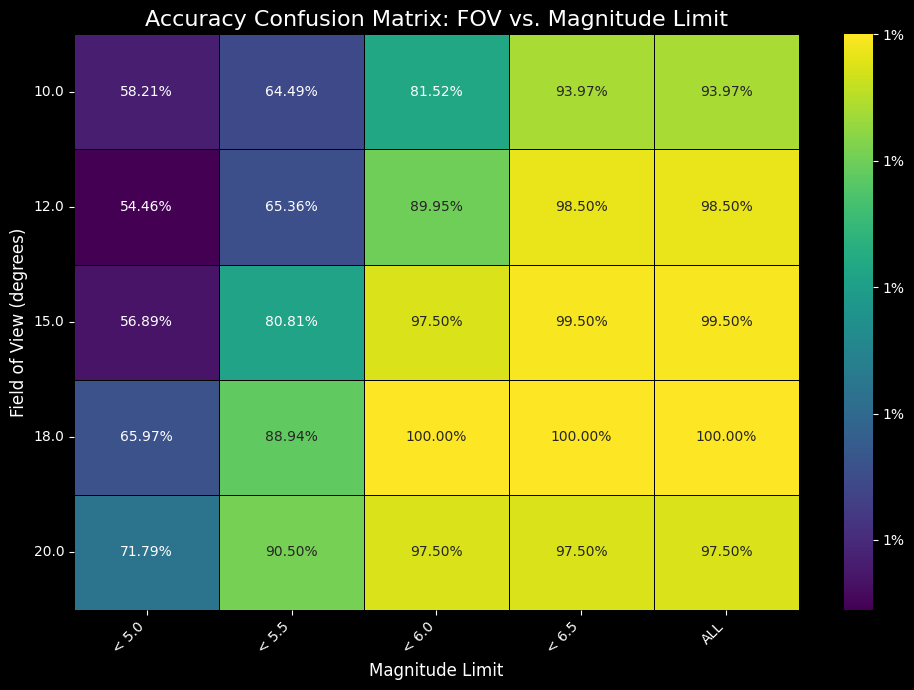

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the DataFrame for heatmap: Convert percentages to floats and set FOV as index
confusion_numeric = confusion_df.set_index('FOV').apply(lambda x: x.str.rstrip('%').astype(float) / 100)

plt.figure(figsize=(10, 7))
sns.heatmap(
    confusion_numeric,
    annot=True,        # Show the accuracy values on the heatmap
    fmt=".2%",         # Format annotations as percentages
    cmap="viridis",    # Choose a color map
    linewidths=.5,     # Add lines between cells
    linecolor='black', # Color of the lines
    cbar_kws={'format': '%.0f%%'} # Format color bar as percentages
)

plt.title('Accuracy Confusion Matrix: FOV vs. Magnitude Limit', fontsize=16)
plt.xlabel('Magnitude Limit', fontsize=12)
plt.ylabel('Field of View (degrees)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()